In [1]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn import datasets
from sklearn.tree import DecisionTreeClassifier
import numpy as np
from Testers import Tester
import pandas as pd
import random

In [2]:
seed = 42
np.random.seed(seed)
random.seed(seed)
data = datasets.load_digits()


X = data.data
y = data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True)

In [4]:
from Bagging import create_bags, create_models, get_accuracy
from BaggingGEN import BaggingGEN

reps = 10
n_trees = [5, 10, 15]

res = []
for n_tree in n_trees:
    for rep in range(reps):
        print(f"[REP] {reps} [N_TREES] {n_tree}")
        bagging_gen = BaggingGEN(X=X_train, y=y_train, n_trees=n_tree, max_iterations=100, mutation_rate=0.1, crossover_rate=0.8, population_size=50)
        models_fitted, models_init, fitness = bagging_gen.run_genetic_algorithm()
        
        accuracy_fitted = get_accuracy(X=X_test, y=y_test, models=models_fitted)
        # accuracy_init = get_accuracy(X=X_test, y=y_test, models=models_init)
        
        
        
        #!TEST 
        bags = create_bags(X_train, y_train, n_bags=n_tree, with_replacement=False)
        models = create_models(bags, n_trees=n_tree)
        accuracy_init = get_accuracy(X=X_test, y=y_test, models=models)
        
        
        
        
        res.append([n_tree, rep, accuracy_fitted, accuracy_init, fitness]) 
        print(f"Accuracy fitted: {accuracy_fitted} | Accuracy init: {accuracy_init}")
        
        df = pd.DataFrame(res, columns=["n_trees", "rep", "accuracy_fitted", "accuracy_init", "fitness"])
        df.to_csv(f"./../res/bagging_gen_fitness.csv", index=False)

[REP] 10 [N_TREES] 5
Iteration: 0, Best fitness: 0.899, Current fitness: 0.899
Iteration: 1, Best fitness: 0.900, Current fitness: 0.900
Iteration: 2, Best fitness: 0.900, Current fitness: 0.897
Iteration: 3, Best fitness: 0.900, Current fitness: 0.897
Iteration: 4, Best fitness: 0.900, Current fitness: 0.897
Iteration: 5, Best fitness: 0.900, Current fitness: 0.893
Iteration: 6, Best fitness: 0.900, Current fitness: 0.896
Iteration: 7, Best fitness: 0.900, Current fitness: 0.893
Iteration: 8, Best fitness: 0.900, Current fitness: 0.894
Iteration: 9, Best fitness: 0.900, Current fitness: 0.900
Iteration: 10, Best fitness: 0.900, Current fitness: 0.900
Iteration: 11, Best fitness: 0.902, Current fitness: 0.902
Iteration: 12, Best fitness: 0.902, Current fitness: 0.901
Iteration: 13, Best fitness: 0.902, Current fitness: 0.897
Iteration: 14, Best fitness: 0.902, Current fitness: 0.901
Iteration: 15, Best fitness: 0.903, Current fitness: 0.903
Iteration: 16, Best fitness: 0.903, Current f

KeyboardInterrupt: 

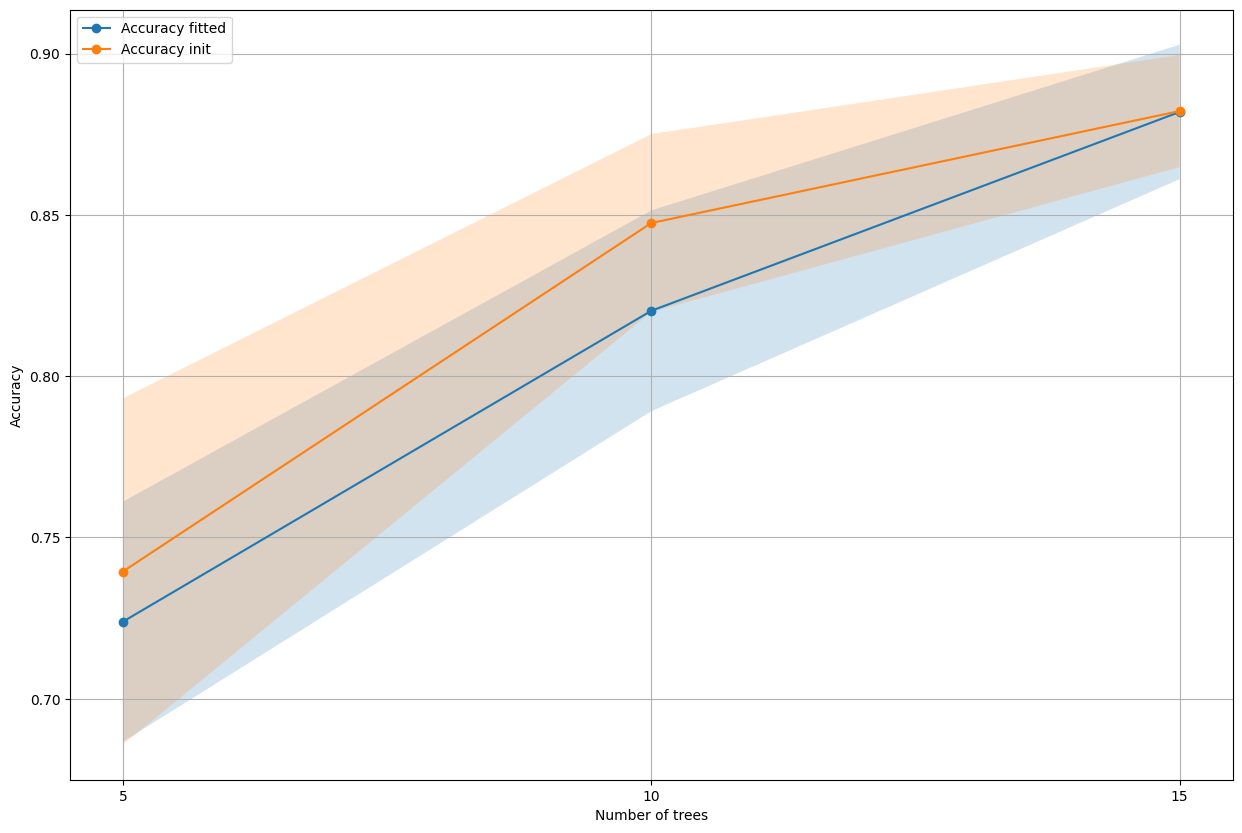

In [ ]:
# Create plot
import matplotlib.pyplot as plt
import pandas as pd

n_trees = [5, 10, 15]


X = n_trees

plt.figure(figsize=(15, 10))
df = pd.read_csv(f"./../res/bagging_gen_fitness.csv") 

Y1 = df.groupby("n_trees")["accuracy_fitted"].mean()
Y_std1 = df.groupby("n_trees")["accuracy_fitted"].std()
Y2 = df.groupby("n_trees")["accuracy_init"].mean()
Y_std2 = df.groupby("n_trees")["accuracy_init"].std()

plt.plot(X, Y1, label="Accuracy fitted", marker='o')
plt.fill_between(X, Y1 - Y_std1, Y1 + Y_std1, alpha=0.2)
plt.plot(X, Y2, label="Accuracy init", marker='o')
plt.fill_between(X, Y2 - Y_std2, Y2 + Y_std2, alpha=0.2)
plt.xlabel("Number of trees")
plt.ylabel("Accuracy")
plt.xticks(X)
plt.grid()
plt.legend()

plt.show()

ValueError: x and y must have same first dimension, but have shapes (30,) and (27,)

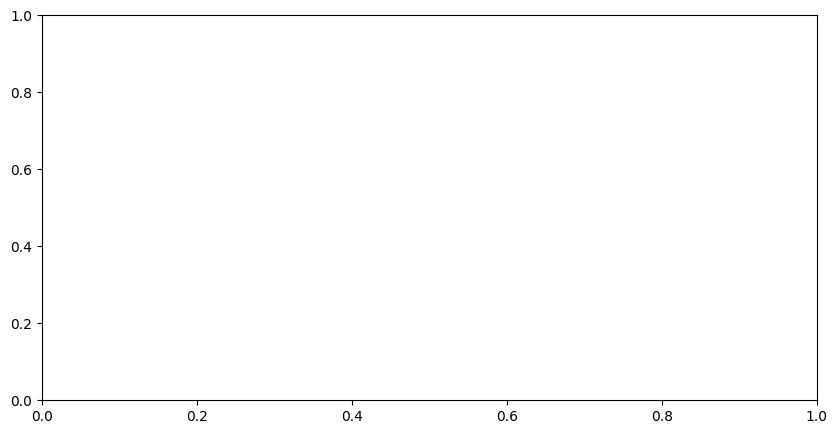

In [ ]:
# fitness vs accuracy
X = df["fitness"]
Y1 = df.groupby("fitness")["accuracy_fitted"].mean()
Y_std1 = df.groupby("fitness")["accuracy_fitted"].std()
Y2 = df.groupby("fitness")["accuracy_init"].mean()
Y_std2 = df.groupby("fitness")["accuracy_init"].std()
plt.figure(figsize=(10, 5))
plt.plot(X, Y1, label="Accuracy fitted", marker='o')
plt.fill_between(X, Y1 - Y_std1, Y1 + Y_std1, alpha=0.2)
plt.plot(X, Y2, label="Accuracy init", marker='o')
plt.fill_between(X, Y2 - Y_std2, Y2 + Y_std2, alpha=0.2)
plt.title("BAccuracy vs Fitness")
plt.xlabel("Fitness")
plt.ylabel("Accuracy")
plt.xticks(X)
plt.grid()
plt.legend()
plt.show()
